# Leakage Experiment

Notebook này là nơi trình bày báo cáo cho thí nghiệm rò rỉ dữ liệu. Logic SQL và huấn luyện model dùng chung nằm trong `src/pit_feature_store/leakage.py`; notebook chỉ import lại logic đó, vẽ biểu đồ, kiểm tra các chỉ số đã duyệt và xuất artifact báo cáo.

## Experiment Contract

- Feature PIT dùng cửa sổ `[cutoff - window, cutoff)`.
- Feature chỉ nhìn tương lai dùng cửa sổ `(cutoff, cutoff + window]` với cùng tên feature và cùng độ dài window như PIT.
- `pit_plus_future` giữ nguyên các feature PIT và thêm các feature tương lai được đặt tên rõ ràng.
- Cách chia train/test dựa theo thời gian, không random, và các dòng có cùng timestamp luôn nằm cùng một phía của split.

In [6]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import precision_recall_curve, roc_curve
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)


project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if not (project_root / 'src' / 'pit_feature_store').exists():
    project_root = project_root.parent

src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from pit_feature_store.leakage import run_experiment

database_path = project_root / 'artifacts' / 'warehouse.duckdb'
catalog_path = project_root / 'config' / 'feature_catalog.yaml'
report_dir = project_root / 'artifacts' / 'reports'
metrics_path = report_dir / 'leakage_metrics.csv'
markdown_path = report_dir / 'leakage_experiment.md'

database_path, catalog_path, metrics_path, markdown_path

(WindowsPath('c:/Users/tiennd49/Documents/point-in-time-feature-store/artifacts/warehouse.duckdb'),
 WindowsPath('c:/Users/tiennd49/Documents/point-in-time-feature-store/config/feature_catalog.yaml'),
 WindowsPath('c:/Users/tiennd49/Documents/point-in-time-feature-store/artifacts/reports/leakage_metrics.csv'),
 WindowsPath('c:/Users/tiennd49/Documents/point-in-time-feature-store/artifacts/reports/leakage_experiment.md'))

## Run Experiment

Module trả về các chỉ số và prediction score, không tự in và không tự vẽ. Notebook chịu trách nhiệm hiển thị kết quả và xuất artifact.

In [7]:
experiment = run_experiment(database_path=database_path, catalog_path=catalog_path)
metrics = experiment['metrics']
predictions = experiment['predictions']
report_markdown = experiment['markdown']

display(metrics)
metrics[['dataset', 'roc_auc', 'pr_auc', 'pr_auc_lift']]

,dataset,eligible_start,eligible_end,total_rows,eligible_rows,excluded_rows,split_ts,train_rows,test_rows,train_positive,test_positive,test_fraud_rate,feature_count,feature_columns,roc_auc,pr_auc,pr_auc_lift
0,pit,2018-01-01 00:00:00,2018-05-02 23:58:51,590540,370770,219770,2018-04-05 23:19:56,296615,74155,11741,2527,0.034077,4,sum_amt_24h|count_txn_24h|sum_amt_7d|time_sinc...,0.679783,0.067894,1.992364
1,future_only,2018-01-01 00:00:00,2018-05-02 23:58:51,590540,370770,219770,2018-04-05 23:19:56,296615,74155,11741,2527,0.034077,4,sum_amt_24h|count_txn_24h|sum_amt_7d|time_sinc...,0.674214,0.064931,1.905402
2,pit_plus_future,2018-01-01 00:00:00,2018-05-02 23:58:51,590540,370770,219770,2018-04-05 23:19:56,296615,74155,11741,2527,0.034077,8,sum_amt_24h|count_txn_24h|sum_amt_7d|time_sinc...,0.705485,0.074536,2.187256


,dataset,roc_auc,pr_auc,pr_auc_lift
0,pit,0.679783,0.067894,1.992364
1,future_only,0.674214,0.064931,1.905402
2,pit_plus_future,0.705485,0.074536,2.187256


## Metric Validation

Các giá trị bên dưới được so với kết quả Giai đoạn 4 đã duyệt và đã ghi trong `STATUS.md`.

In [8]:
expected = {
    'pit': {'roc_auc': 0.679783, 'pr_auc': 0.067894},
    'future_only': {'roc_auc': 0.674214, 'pr_auc': 0.064931},
    'pit_plus_future': {'roc_auc': 0.705485, 'pr_auc': 0.074536},
}
indexed = metrics.set_index('dataset')
deltas = []
for dataset, expected_metrics in expected.items():
    for metric_name, expected_value in expected_metrics.items():
        actual_value = float(indexed.loc[dataset, metric_name])
        delta = actual_value - expected_value
        deltas.append(
            {
                'dataset': dataset,
                'metric': metric_name,
                'expected': expected_value,
                'actual': actual_value,
                'delta': delta,
            }
        )
        assert abs(delta) < 1e-6

delta_frame = pd.DataFrame(deltas)
display(delta_frame)
assert indexed.loc['pit', 'eligible_start'] == '2018-01-01 00:00:00'
assert indexed.loc['pit', 'eligible_end'] == '2018-05-02 23:58:51'
assert indexed.loc['pit', 'split_ts'] == '2018-04-05 23:19:56'
delta_frame

,dataset,metric,expected,actual,delta
0,pit,roc_auc,0.679783,0.679783,2.391022e-07
1,pit,pr_auc,0.067894,0.067894,3.276238e-07
2,future_only,roc_auc,0.674214,0.674214,2.657078e-08
3,future_only,pr_auc,0.064931,0.064931,-8.442102e-08
4,pit_plus_future,roc_auc,0.705485,0.705485,7.514388e-08
5,pit_plus_future,pr_auc,0.074536,0.074536,-2.984340e-07


,dataset,metric,expected,actual,delta
0,pit,roc_auc,0.679783,0.679783,2.391022e-07
1,pit,pr_auc,0.067894,0.067894,3.276238e-07
2,future_only,roc_auc,0.674214,0.674214,2.657078e-08
3,future_only,pr_auc,0.064931,0.064931,-8.442102e-08
4,pit_plus_future,roc_auc,0.705485,0.705485,7.514388e-08
5,pit_plus_future,pr_auc,0.074536,0.074536,-2.984340e-07


## ROC and PR Curves

Các đường cong được vẽ trực tiếp trong notebook từ prediction score trả về. Module tái sử dụng không chứa code vẽ biểu đồ.

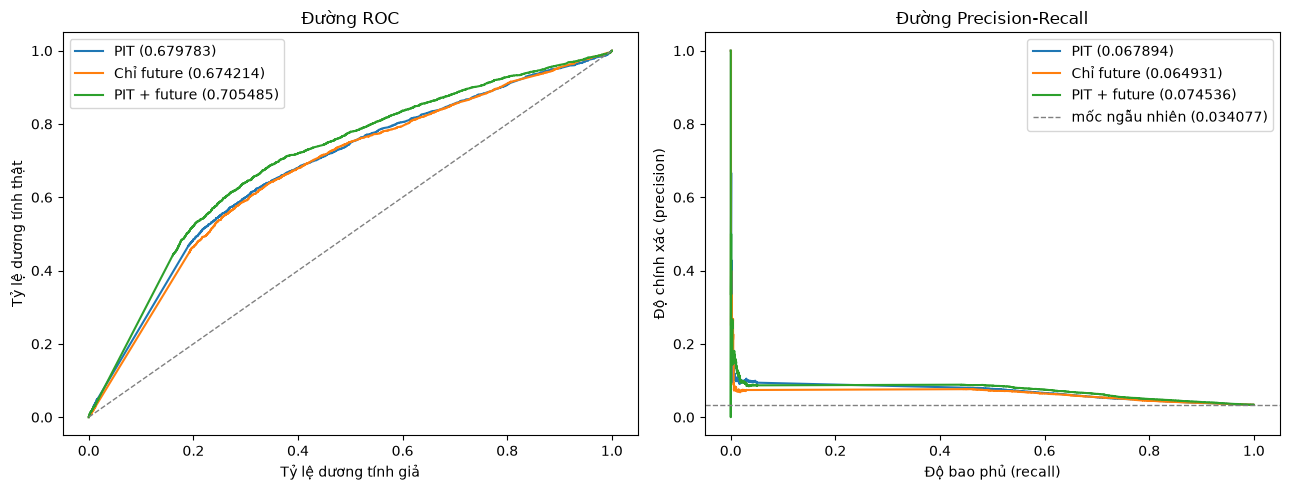

In [9]:
dataset_display_names = {
    'pit': 'PIT',
    'future_only': 'Chỉ future',
    'pit_plus_future': 'PIT + future',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for dataset_name, group in predictions.groupby('dataset', sort=False):
    metric_row = indexed.loc[dataset_name]
    display_name = dataset_display_names.get(dataset_name, dataset_name)
    fpr, tpr, _ = roc_curve(group['label'], group['score'])
    precision, recall, _ = precision_recall_curve(group['label'], group['score'])
    axes[0].plot(
        fpr,
        tpr,
        label=f"{display_name} ({metric_row['roc_auc']:.6f})",
    )
    axes[1].plot(
        recall,
        precision,
        label=f"{display_name} ({metric_row['pr_auc']:.6f})",
    )

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
axes[0].set_title('Đường ROC')
axes[0].set_xlabel('Tỷ lệ dương tính giả')
axes[0].set_ylabel('Tỷ lệ dương tính thật')
axes[0].legend()

baseline = float(indexed.loc['pit', 'test_fraud_rate'])
axes[1].axhline(baseline, linestyle='--', color='gray', linewidth=1, label=f'mốc ngẫu nhiên ({baseline:.6f})')
axes[1].set_title('Đường Precision-Recall')
axes[1].set_xlabel('Độ bao phủ (recall)')
axes[1].set_ylabel('Độ chính xác (precision)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Analysis Summary

So sánh kiểm soát chính là `pit_plus_future` với `pit`: model mở rộng vẫn giữ các feature PIT nhìn về quá khứ và được thêm feature nhìn về tương lai. Trong lần chạy đã duyệt, ROC-AUC và PR-AUC đều tăng. So sánh `future_only` vẫn hữu ích nhưng là góc nhìn phụ, vì nó thay tín hiệu quá khứ bằng tín hiệu tương lai thay vì thêm tín hiệu tương lai vào cùng nền PIT. Kết quả này là kết quả thực nghiệm; notebook không giả định trước rằng thông tin tương lai chắc chắn làm metric tốt hơn.

## Export Artifacts

Các output báo cáo được ghi vào `artifacts/reports/`.

In [10]:
report_dir.mkdir(parents=True, exist_ok=True)
metrics.to_csv(metrics_path, index=False, float_format='%.10f')
markdown_path.write_text(report_markdown, encoding='utf-8')

roundtrip = pd.read_csv(metrics_path)
pd.testing.assert_frame_equal(roundtrip, metrics, check_dtype=False)

print(f'Đã ghi metrics: {metrics_path}')
print(f'Đã ghi report markdown: {markdown_path}')

Đã ghi metrics: c:\Users\tiennd49\Documents\point-in-time-feature-store\artifacts\reports\leakage_metrics.csv
Đã ghi report markdown: c:\Users\tiennd49\Documents\point-in-time-feature-store\artifacts\reports\leakage_experiment.md
